In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = sns.load_dataset("taxis")
print(df.head())



               pickup             dropoff  passengers  distance  fare   tip  \
0 2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0  2.15   
1 2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0  0.00   
2 2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5  2.36   
3 2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0  6.15   
4 2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0  1.10   

   tolls  total   color      payment            pickup_zone  \
0    0.0  12.95  yellow  credit card        Lenox Hill West   
1    0.0   9.30  yellow         cash  Upper West Side South   
2    0.0  14.16  yellow  credit card          Alphabet City   
3    0.0  36.95  yellow  credit card              Hudson Sq   
4    0.0  13.40  yellow  credit card           Midtown East   

            dropoff_zone pickup_borough dropoff_borough  
0    UN/Turtle Bay South      Manhattan       Manhattan  
1  Upper West Side South      

In [5]:
print(df.head())
print(df.info)
print(df.describe())

               pickup             dropoff  passengers  distance  fare   tip  \
0 2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0  2.15   
1 2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0  0.00   
2 2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5  2.36   
3 2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0  6.15   
4 2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0  1.10   

   tolls  total   color      payment            pickup_zone  \
0    0.0  12.95  yellow  credit card        Lenox Hill West   
1    0.0   9.30  yellow         cash  Upper West Side South   
2    0.0  14.16  yellow  credit card          Alphabet City   
3    0.0  36.95  yellow  credit card              Hudson Sq   
4    0.0  13.40  yellow  credit card           Midtown East   

            dropoff_zone pickup_borough dropoff_borough  
0    UN/Turtle Bay South      Manhattan       Manhattan  
1  Upper West Side South      

In [7]:
df.isnull()
df.isnull().sum()


,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,44


In [9]:
#handling missing values
df["payment"] = df["payment"].fillna(df["payment"].mode()[0])
df["pickup_zone"] = df["pickup_zone"].fillna(df["pickup_zone"].mode()[0])
df["dropoff_zone"] = df["dropoff_zone"].fillna(df["dropoff_zone"].mode()[0])
df["pickup_borough"] = df["pickup_borough"].fillna(df["pickup_borough"].mode()[0])
df["dropoff_borough"] = df["dropoff_borough"].fillna(df["dropoff_borough"].mode()[0])

In [10]:
df.isnull()
df.isnull().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,0


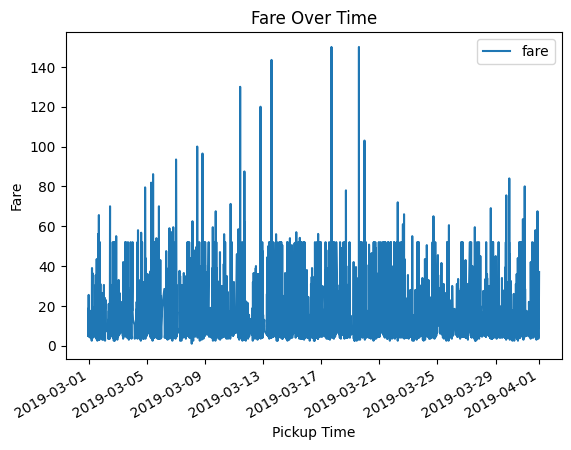

In [12]:
df["pickup"] = pd.to_datetime(df["pickup"])

df = df.sort_values("pickup")
df.plot(x="pickup", y="fare", kind="line")

plt.title("Fare Over Time")
plt.xlabel("Pickup Time")
plt.ylabel("Fare")

plt.show()

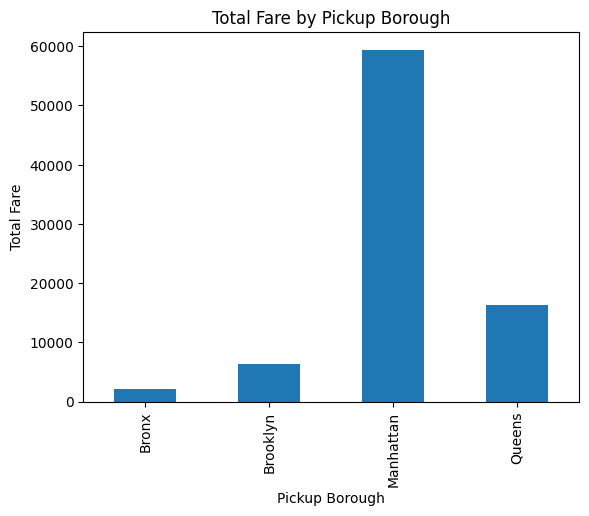

In [13]:
df.groupby("pickup_borough")["fare"].sum().plot(kind="bar")
plt.title("Total Fare by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Total Fare")
plt.show()

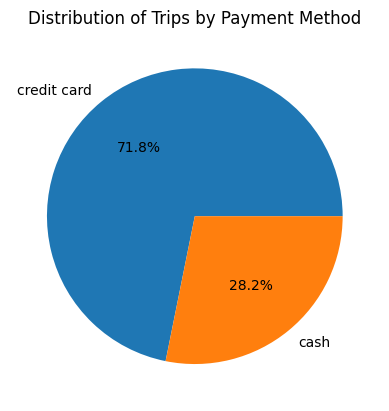

In [14]:
#piechart
payment_counts = df["payment"].value_counts()

plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct="%1.1f%%"
)
plt.title("Distribution of Trips by Payment Method")
plt.show()

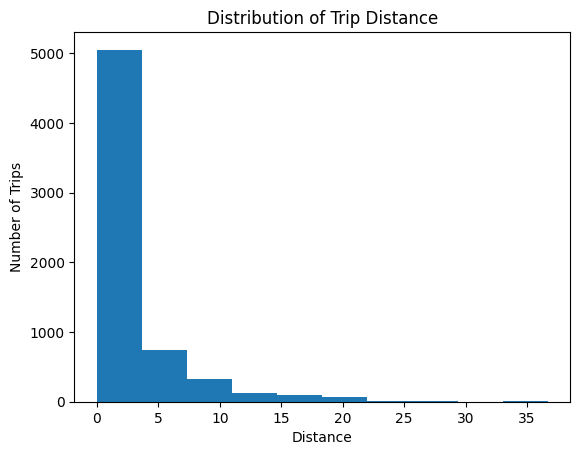

In [16]:
#HISTOGRAM
plt.hist(df["distance"], bins=10)

plt.title("Distribution of Trip Distance")
plt.xlabel("Distance")
plt.ylabel("Number of Trips")
plt.show()

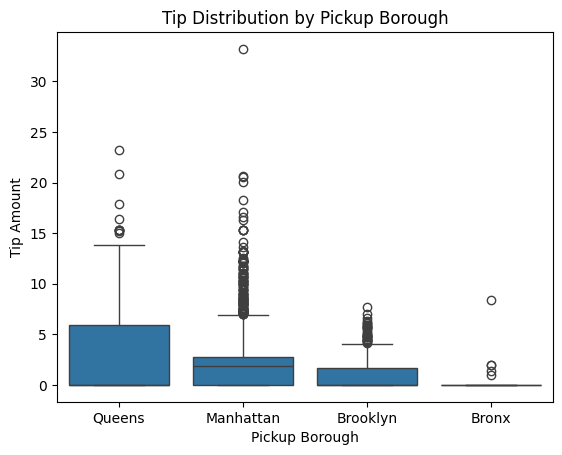

In [17]:
#BOXPLOT
sns.boxplot(x="pickup_borough", y="tip", data=df)

plt.title("Tip Distribution by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Tip Amount")
plt.show()

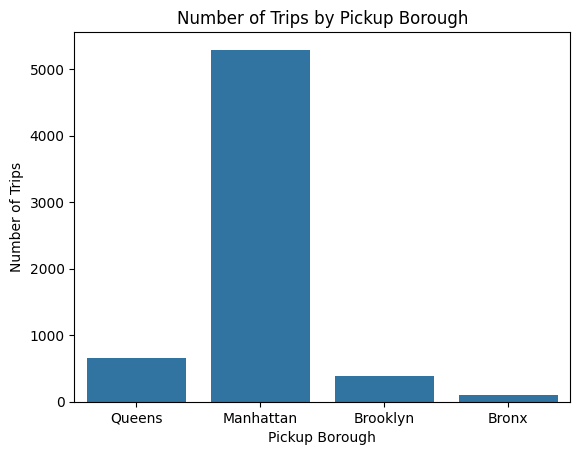

In [18]:
#COUNTPLOT SEABORN
sns.countplot(x="pickup_borough", data=df)

plt.title("Number of Trips by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Number of Trips")
plt.show()

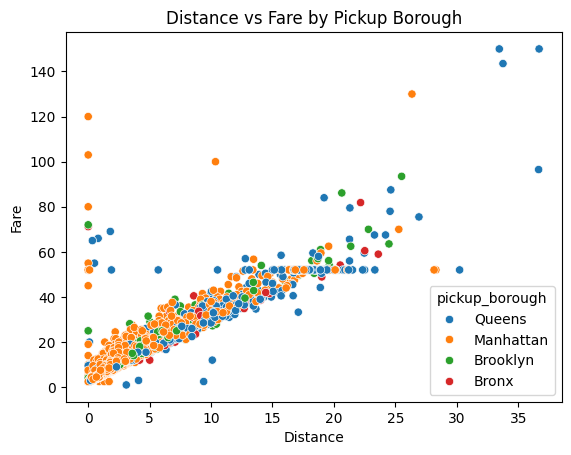

In [21]:
#SCATTER PLOT
df = df.dropna(subset=["distance", "fare", "pickup_borough"])

sns.scatterplot(
    data=df,
    x="distance",
    y="fare",
    hue="pickup_borough"
)

plt.title("Distance vs Fare by Pickup Borough")
plt.xlabel("Distance")
plt.ylabel("Fare")
plt.show()

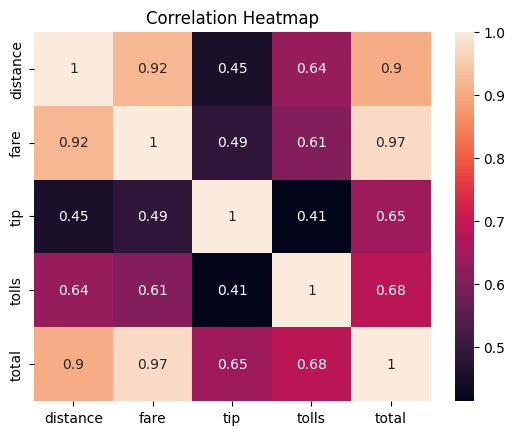

In [22]:
#HEATMAP
correlation = df[["distance", "fare", "tip", "tolls", "total"]].corr()

sns.heatmap(correlation, annot=True)

plt.title("Correlation Heatmap")
plt.show()

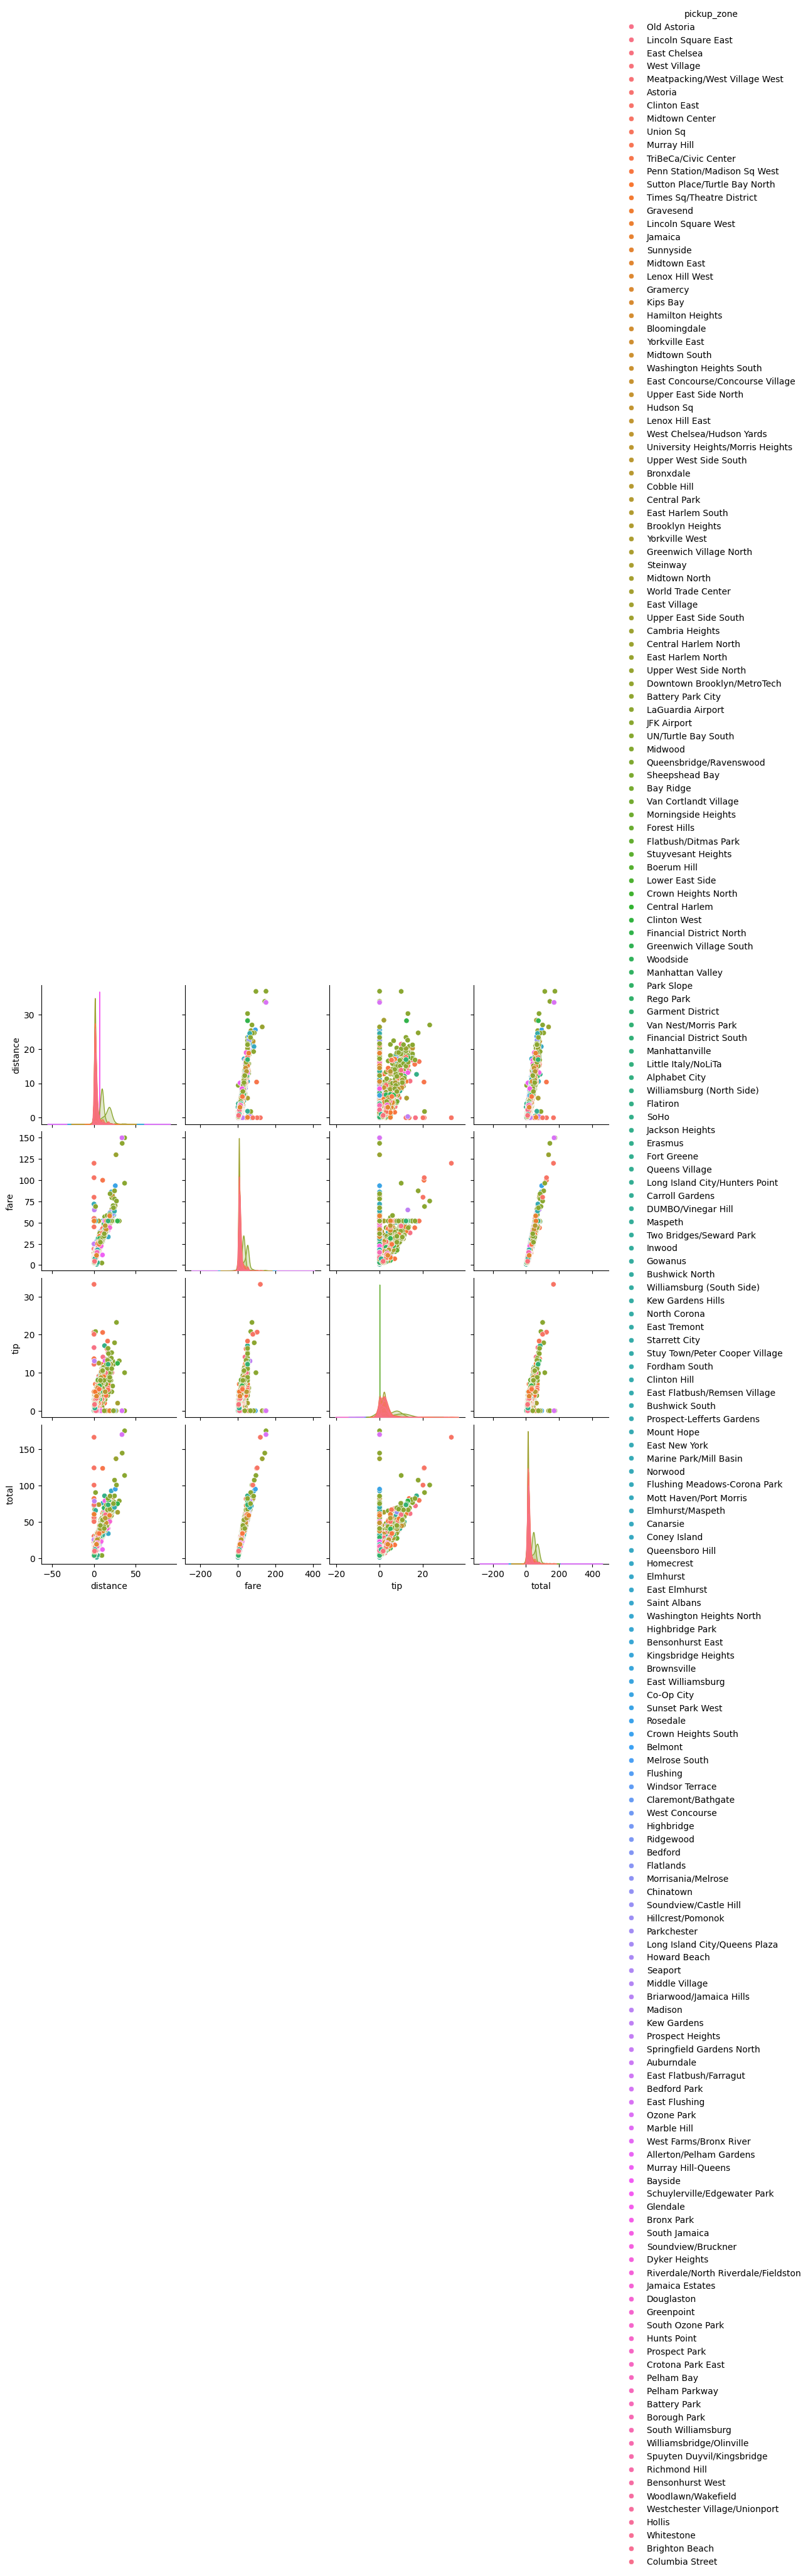

In [25]:
#PAIRPLOT
sns.pairplot(
    df[["distance", "fare", "tip", "total", "pickup_zone"]].dropna(),
    hue="pickup_zone"
)

plt.show()

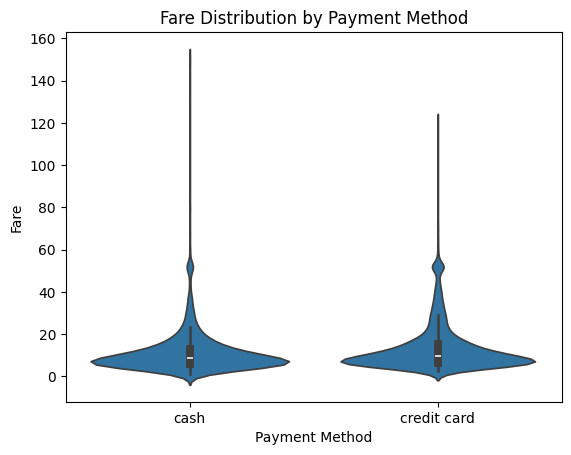

In [26]:
#VIOLIN PLOT
sns.violinplot(
    data=df,
    x="payment",
    y="fare"
)

plt.title("Fare Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Fare")
plt.show()